<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/main/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [6]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [8]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [25]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [26]:
# 使わない列の削除
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [21]:
# 平均で補完する対象の列
cols_to_fill = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']

# train の平均で train/test 両方を補完
for col in cols_to_fill:
        mean_value = train[col].mean()
        train[col] = train[col].fillna(mean_value)
        test[col] = test[col].fillna(mean_value)

In [27]:
train.isnull().sum()

,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581
Agility_3cone,970


In [28]:
test.isnull().sum()

,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147
Agility_3cone,247


In [29]:
# カテゴリデータをラベルエンコーディング
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

## 6. 仮説と特徴量エンジニアリング

In [30]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

    # df['BigFour'] = df['School'].apply(lambda x: 1 if x in BigFour else 0)
    # df['Power5'] = df['School'].apply(lambda x: 1 if x in Power5 else 0)

    df.drop(columns=['School'],axis=1, inplace=True)

In [31]:
X = train.drop(columns=['Drafted'])
y = train['Drafted']

sampler = TPESampler(seed=42)

# Define objective function specifically for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = XGBClassifier(**params, random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss',
                          verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, y_pred_proba)
        auc_scores.append(auc)

    return np.mean(auc_scores)

# Optimize only XGBoost
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, n_jobs=1)

best_params = study.best_params
print(f"XGBoost best params: {best_params}")
print(f"Best AUC: {study.best_value:.4f}\n")

# Build optimized XGBoost model
optimized_model = XGBClassifier(**best_params, random_state=42,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                verbosity=0)

# Evaluate using stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\n=== XGBoost Evaluation ===')
auc_scores = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f'Fold{fold+1}')

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    optimized_model.fit(X_train, y_train)

    y_valid_pred_proba = optimized_model.predict_proba(X_valid)[:,1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f'AUC:{round(auc,4)}')

    test_pred_proba = optimized_model.predict_proba(test)[:,1]
    test_pred_proba_list.append(test_pred_proba)

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

[I 2025-07-01 11:56:55,148] A new study created in memory with name: no-name-799b377e-6976-4994-be73-434a208c2f26
[I 2025-07-01 11:56:56,689] Trial 0 finished with value: 0.8134174607764834 and parameters: {'n_estimators': 218, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.8134174607764834.
[I 2025-07-01 11:56:58,610] Trial 1 finished with value: 0.8118811373189093 and parameters: {'n_estimators': 440, 'max_depth': 10, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.8134174607764834.
[I 2025-07-01 11:56:59,192] Trial 2 finished with value: 0.8324526843907532 and parameters: {'n_estimators': 132, 'max_depth': 5, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119,

XGBoost best params: {'n_estimators': 112, 'max_depth': 6, 'learning_rate': 0.03476649150592621, 'subsample': 0.728034992108518, 'colsample_bytree': 0.8925879806965068, 'gamma': 0.19967378215835974, 'min_child_weight': 6}
Best AUC: 0.8325


=== XGBoost Evaluation ===
Fold1
AUC:0.8129
Fold2
AUC:0.851
Fold3
AUC:0.8561
Fold4
AUC:0.7926
Fold5
AUC:0.8497

Average Validation AUC: 0.8325



=== Feature Importances ===
             Feature  Importance
1                Age    0.445001
10       Player_Type    0.059973
4        Sprint_40yd    0.059738
3             Weight    0.056749
2             Height    0.047598
6   Bench_Press_Reps    0.045314
9            Shuttle    0.040206
13               BMI    0.040094
8      Agility_3cone    0.038600
12          Position    0.038181
7         Broad_Jump    0.035083
5      Vertical_Jump    0.034840
11     Position_Type    0.033378
0               Year    0.025244


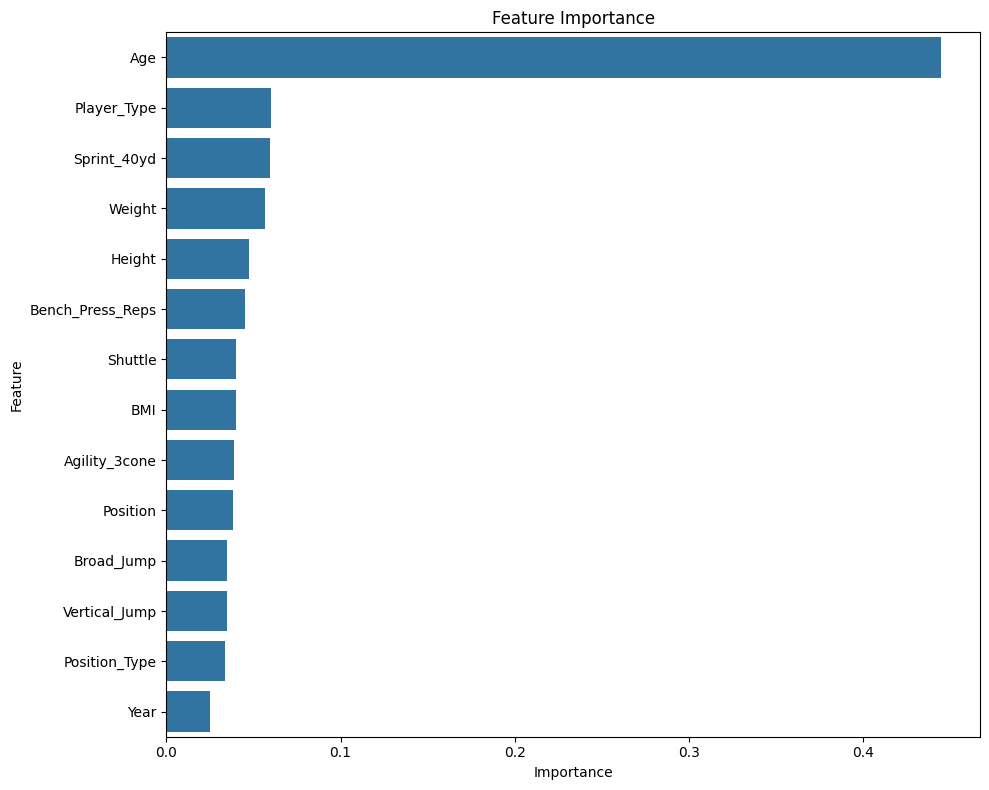

In [33]:
# prompt: モデルの特徴量重要度を知りたい

import pandas as pd
import matplotlib.pyplot as plt
# 特徴量重要度を取得
feature_importances = optimized_model.feature_importances_

# 特徴量名と重要度を組み合わせる
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 重要度で降順にソート
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 結果を表示
print("\n=== Feature Importances ===")
print(importance_df)

# 特徴量重要度を可視化 (オプション)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [34]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！